## Load Packages and configure Notebook

In [12]:
# import packages
import pandas as pd
import os
import random
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split

# change directory
os.chdir('/Users/philipp/desktop/ML_in_Applied_Settings')
# print current directory
print(os.getcwd())

# optimize printed dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

/Users/philipp/Desktop/ML_in_Applied_Settings


## Load in datasets

In [13]:
# read in both datasets
human_df = pd.read_csv("human_reviews_labeled.csv", sep="\t")
ai_df = pd.read_csv("df_API_test_2.csv", sep="\t")

In [14]:
# set human generated label for dataset before merging
human_df.head() 
human_df["ai_generated"] = 0


In [15]:
# set ai generated label for dataset before merging
ai_df["ai_generated"] = 1
ai_df.head()

,category,product,rating,title,text,ai_generated
0,Clothing_Shoes_and_Jewelry,Leather Biker Jacket,5,Absolutely stunning,"I was hesitant to buy leather online, but this...",1
1,Clothing_Shoes_and_Jewelry,Cotton V-Neck T-Shirts,5,Great value,Perfect basic tees.,1
2,Clothing_Shoes_and_Jewelry,Running Shoes,5,Cloud-like comfort,I use these for my morning jogs and they are i...,1
3,Clothing_Shoes_and_Jewelry,Floral Summer Dress,3,It's okay,The pattern is beautiful and the fabric is lig...,1
4,Clothing_Shoes_and_Jewelry,Gold Plated Hoops,3,Average,"They look nice at first, but I noticed some fa...",1


In [16]:
# reorder ai_df
new_order= ["rating", "title", "text", "category", "ai_generated"]

# DataFrame mit der neuen Reihenfolge überschreiben
ai_df = ai_df[new_order]
ai_df.head()


,rating,title,text,category,ai_generated
0,5,Absolutely stunning,"I was hesitant to buy leather online, but this...",Clothing_Shoes_and_Jewelry,1
1,5,Great value,Perfect basic tees.,Clothing_Shoes_and_Jewelry,1
2,5,Cloud-like comfort,I use these for my morning jogs and they are i...,Clothing_Shoes_and_Jewelry,1
3,3,It's okay,The pattern is beautiful and the fabric is lig...,Clothing_Shoes_and_Jewelry,1
4,3,Average,"They look nice at first, but I noticed some fa...",Clothing_Shoes_and_Jewelry,1


In [17]:
columns_to_drop = ["verified_purchase", "language", "year", "date_only", "text_length", "label"]

human_df = human_df.drop(columns=columns_to_drop)
human_df["rating"] = human_df["rating"].astype("int")


In [18]:
combined_df = pd.concat([human_df, ai_df], axis=0, ignore_index=True)
combined_df.head()

,rating,title,text,category,ai_generated
0,5,Best investment this summer,"Since I’m so aware of sun protection, I need a...",Clothing_Shoes_and_Jewelry,0
1,5,Wear socks,I have to wear socks with them. They gave me b...,Clothing_Shoes_and_Jewelry,0
2,5,Excellent product,"Very good quality, easy to install and works g...",Tools_and_Home_Improvement,0
3,5,Hair moisture,This is wonderful for my 4C hair. I will buy a...,Beauty_and_Personal_Care,0
4,5,Great battery,These batteries work for a really long time! W...,Health_and_Household,0


In [19]:
# --- Clean HTML tags and entities from review text ---
# Amazon reviews can contain leftover HTML such as <br>, <br/>, &lt;, &amp; etc.
# These artefacts are strong confounds: TF-IDF picks up 'br' as a top indicator
# for human-written reviews instead of genuine writing style.

import html as html_module

def clean_html(text):
    s = str(text)
    s = html_module.unescape(s)              # &lt; -> <, &amp; -> &, &nbsp; -> space, etc.
    s = re.sub(r'<[^>]+>', ' ', s)           # remove HTML tags such as <br>, <br/>, <a>, ...
    s = re.sub(r'\bbr\b', ' ', s, flags=re.IGNORECASE)  # remove orphan 'br' tokens left after tag removal
    s = re.sub(r'\s+', ' ', s).strip()      # collapse whitespace
    return s

combined_df['text'] = combined_df['text'].astype(str).map(clean_html)
print('HTML cleaning applied.')

HTML cleaning applied.


In [20]:
combined_df.isna().sum()

rating          0
title           0
text            0
category        0
ai_generated    0
dtype: int64

## Split dataset into train and test-set

In [21]:
# first split train and test/validation sets
train_df, test_val_df = train_test_split(
    combined_df, 
    test_size=0.3, 
    random_state=42,
    stratify=combined_df['ai_generated'] # Important for balanced classes!
)

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_val_df )}")

Training samples: 7000
Test samples: 3000


In [22]:
# further split test and valdiation set into seperate sets
validation_df, test_df = train_test_split(
    test_val_df , 
    test_size=0.50, 
    random_state=42,
    stratify=test_val_df ['ai_generated'] # Important for balanced classes!
)

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Training samples: {len(validation_df)}")


Training samples: 7000
Test samples: 1500
Training samples: 1500


In [23]:
# save datasets
train_df.to_csv("/Users/philipp/desktop/ML_in_Applied_Settings/train.csv", index=False, encoding="utf-8", sep=";")
test_df.to_csv("/Users/philipp/desktop/ML_in_Applied_Settings/test.csv", index=False, encoding="utf-8", sep=";")
validation_df.to_csv("/Users/philipp/desktop/ML_in_Applied_Settings/validation.csv", index=False, encoding="utf-8", sep=";")


# EDA

In [24]:
train_df.head()

,rating,title,text,category,ai_generated
6866,2,Disappointing battery,"The features are okay, but the battery barely ...",Electronics,1
2473,5,Love this pillow case.,I've bought the brand of pillow case many time...,Home_and_Kitchen,0
2856,5,Fits a big guy!,[[VIDEOID:35d1cafd2b619e98d3493d14e73e84f4]] H...,Clothing_Shoes_and_Jewelry,0
1671,5,Mums the word,This flower is much darker than red. It is sti...,Home_and_Kitchen,0
5483,3,Leaks a bit.,"It boils water very quickly, which is great, b...",Home_and_Kitchen,1


In [25]:
# get info of dataframe
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7000 entries, 6866 to 131
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   rating        7000 non-null   int64 
 1   title         7000 non-null   object
 2   text          7000 non-null   object
 3   category      7000 non-null   object
 4   ai_generated  7000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 328.1+ KB


In [26]:
# count unique values
train_df.nunique()

rating             5
title           4811
text            6880
category          10
ai_generated       2
dtype: int64

In [27]:
train_df.describe()

,rating,ai_generated
count,7000.000000,7000.000000
mean,4.252000,0.500000
std,1.275545,0.500036
min,1.000000,0.000000
25%,4.000000,0.000000
50%,5.000000,0.500000
75%,5.000000,1.000000
max,5.000000,1.000000


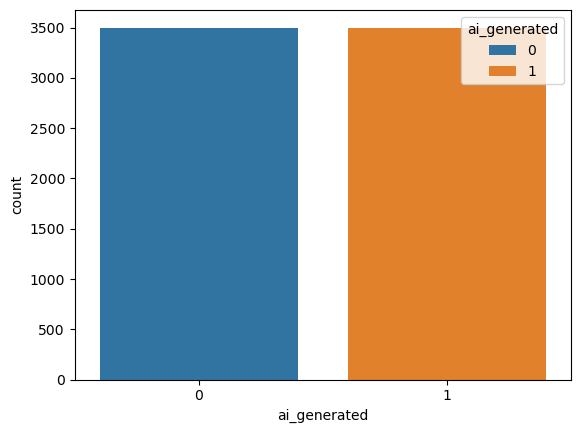

In [28]:
# show distribution of AI-generated and human-written reviews
sns.countplot(train_df, x="ai_generated", hue="ai_generated")
plt.show()

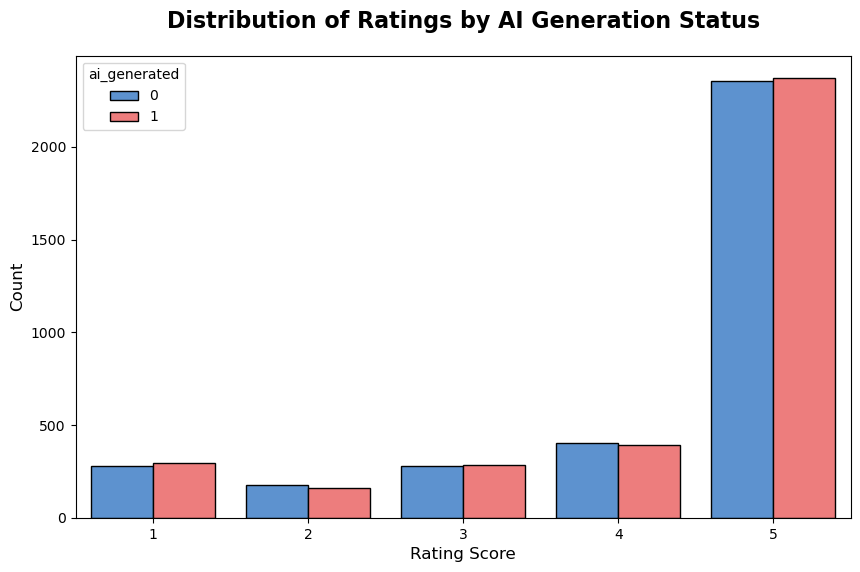

In [29]:
# set a modern palette
colors = ["#4A90E2", "#FF6B6B"] 

# set figure size
plt.figure(figsize=(10, 6))

# create the countplot with improved aesthetics
ax = sns.countplot(
    data=train_df, 
    x="rating", 
    hue="ai_generated", 
    edgecolor="black",
    palette=colors
)

# add title and labels
plt.title("Distribution of Ratings by AI Generation Status", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Rating Score", fontsize=12)
plt.ylabel("Count", fontsize=12)


plt.show()

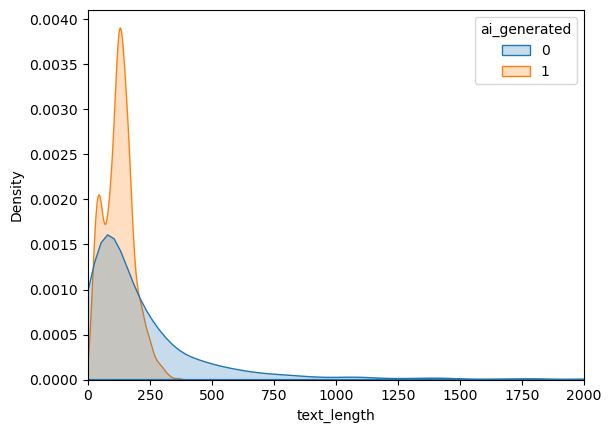

In [ ]:
# create column with text_length
train_df["text_length"] = train_df["text"].apply(lambda x: len(x))
train_df.head()

# show text_length density
sns.kdeplot(train_df, x="text_length", hue="ai_generated", fill=True)
plt.xlim(0,2000)
plt.savefig("avg_sentence_length.pdf", format="pdf", dpi=300)
plt.show()

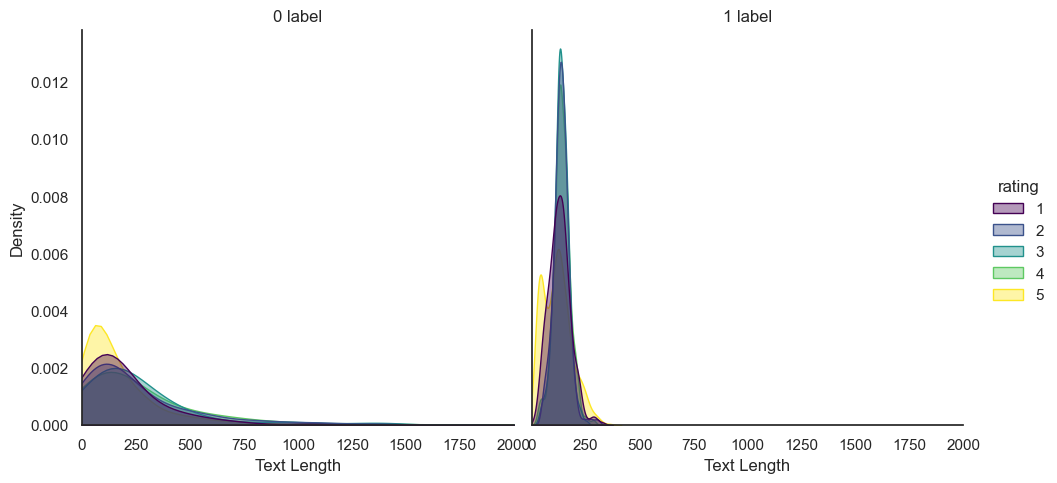

In [31]:
# set a clean style
sns.set_theme(style="white")

# create plot that shows difference in density between labels
g = sns.displot(
    data=train_df, 
    x="text_length", 
    hue="rating", 
    col="ai_generated", 
    kind="kde", 
    fill=True, 
    palette="viridis",
    common_norm=False, 
    alpha=0.4
)

# set limits for all subplots
g.set(xlim=(0, 2000))

# modernize titles and labels
g.set_titles("{col_name} label")
g.set_axis_labels("Text Length", "Density")

plt.show()

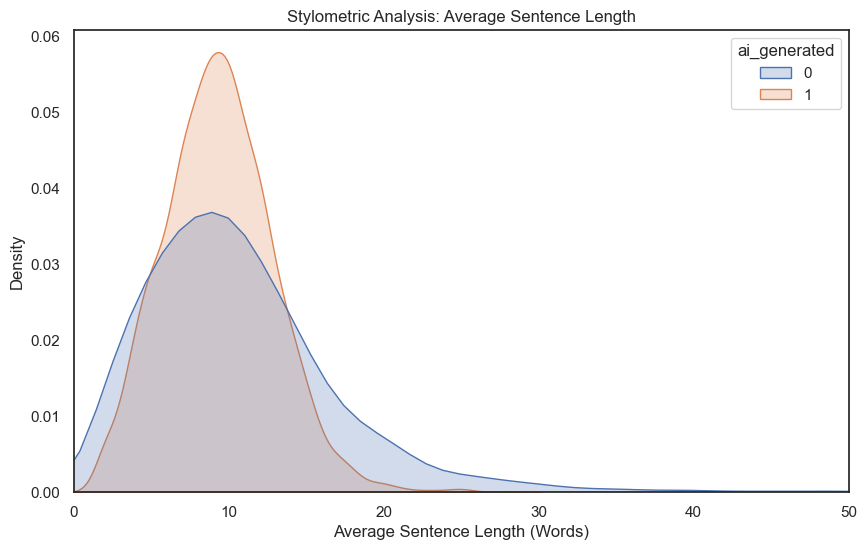

In [ ]:
def calculate_avg_sentence_length(text):
    if not isinstance(text, str) or not text.strip():
        return 0

    # split sentences by simple punctuation 
    sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    if not sentences:
        return 0

    # count words in each sentence and get the average
    word_counts = [len(sentence.split()) for sentence in sentences]

    # return the mean words per sentence
    return sum(word_counts) / len(word_counts)


# apply efficiently to the DataFrame
train_df["avg_sentence_length"] = train_df["text"].apply(
    calculate_avg_sentence_length
)

# Plot the density
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=train_df, x="avg_sentence_length", hue="ai_generated", fill=True
)
plt.xlim(0, 50)  # Most sentences are under 50 words
plt.xlabel("Average Sentence Length (Words)")
plt.ylabel("Density")
plt.title("Stylometric Analysis: Average Sentence Length")
plt.savefig("avg_sentence_length.pdf", format="pdf", dpi=300)
plt.show()

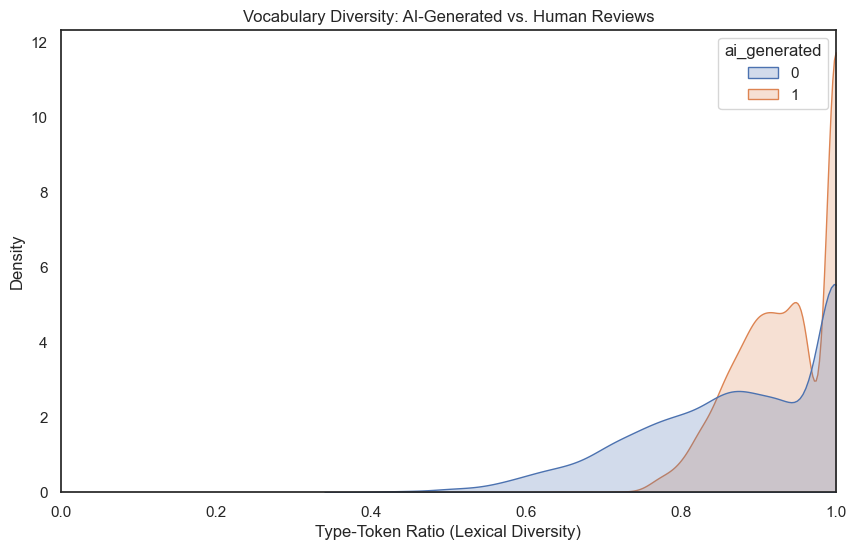

In [ ]:
def calculate_ttr(text):
    if not isinstance(text, str) or not text.strip():
        return 0

    # clean punctuation and lowercase text
    clean_text = re.sub(r"[^\w\s]", "", text.lower())

    # tokenize by splitting on whitespaces
    words = clean_text.split()
    if not words:
        return 0

    # calculate Type-Token Ratio
    return len(set(words)) / len(words)

# create TTR column
train_df["ttr"] = train_df["text"].apply(calculate_ttr)

# plot the TTR density distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train_df, x="ttr", hue="ai_generated", fill=True, common_norm=False)

# TTR is always between 0 and 1, so we limit the x-axis perfectly
plt.xlim(0, 1)

plt.xlabel("Type-Token Ratio (Lexical Diversity)")
plt.ylabel("Density")
plt.title("Vocabulary Diversity: AI-Generated vs. Human Reviews")
plt.savefig("avg_sentence_length.pdf", format="pdf", dpi=300)
plt.show()